# 2. OpenVLA 模型架构

本 Notebook 深入了解 OpenVLA（Open Vision-Language-Action）模型的架构，理解它如何将图像和语言指令转化为机器人/无人机动作。

**学习目标：**
- 理解 OpenVLA 的双视觉编码器 + LLM 架构
- 加载并查看模型结构和参数量
- 理解 Action Tokenizer 的离散化机制
- 掌握 Prompt 格式和推理流程

## 2.1 环境准备

In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# 添加项目路径
PROJECT_ROOT = "/root/autodl-fs/claude/UAV-Flow/OpenVLA-UAV"
sys.path.insert(0, PROJECT_ROOT)

MODEL_PATH = "/root/autodl-fs/claude/models/models--openvla--openvla-7b/snapshots/47a0ec7fc4ec123775a391911046cf33cf9ed83f"

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
GPU: NVIDIA GeForce RTX 3080
显存: 21.0 GB


## 2.2 OpenVLA 架构总览

OpenVLA 是一个 **7B 参数**的视觉-语言-动作模型，架构如下：

```
输入: 无人机 FPV 图像 (224x224) + 语言指令
     ↓
┌──────────────────────────────────────────────────────┐
│  视觉编码器 1: SigLIP-ViT (语义理解)                    │
│  视觉编码器 2: DINOv2-ViT (空间感知)                    │
│        ↓ 融合 + MLP Projector                         │
│  语言模型: Llama 2 7B                                  │
│        ↓ 自回归预测                                     │
│  输出: N 个动作 token → 连续控制量                       │
└──────────────────────────────────────────────────────┘
```

核心思想: **将机器人动作视为语言 token**，利用预训练 LLM 的强大能力来预测动作。

## 2.3 加载模型

In [2]:
# 注册自定义模型到 HuggingFace AutoClass
from prismatic.extern.hf.configuration_prismatic import OpenVLAConfig
from prismatic.extern.hf.modeling_prismatic import OpenVLAForActionPrediction
from prismatic.extern.hf.processing_prismatic import PrismaticProcessor, PrismaticImageProcessor
from transformers import AutoConfig, AutoImageProcessor, AutoProcessor, AutoModelForVision2Seq

AutoConfig.register("openvla", OpenVLAConfig)
AutoImageProcessor.register(OpenVLAConfig, PrismaticImageProcessor)
AutoProcessor.register(OpenVLAConfig, PrismaticProcessor)
AutoModelForVision2Seq.register(OpenVLAConfig, OpenVLAForActionPrediction)

print("OpenVLA 注册完成!")

OpenVLA 注册完成!


In [3]:
# 加载 Processor (包含图像处理器 + 文本 tokenizer)
processor = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True)

print(f"Processor 类型: {type(processor).__name__}")
print(f"Tokenizer 词表大小: {processor.tokenizer.vocab_size}")
print(f"最大序列长度: {processor.tokenizer.model_max_length}")

Processor 类型: PrismaticProcessor
Tokenizer 词表大小: 32000
最大序列长度: 2048


In [4]:
# 加载模型 (bfloat16 精度, 约 14GB 显存)
print("加载 OpenVLA-7B 模型 (需要约 1 分钟)...")
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
).to("cuda:0")
model.eval()

print(f"\n模型加载完成!")
print(f"模型类型: {type(model).__name__}")
print(f"显存占用: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

加载 OpenVLA-7B 模型 (需要约 1 分钟)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


模型加载完成!
模型类型: OpenVLAForActionPrediction
显存占用: 15.1 GB


## 2.4 模型结构分析

In [5]:
# 查看模型的顶层模块
print("OpenVLA 顶层模块:")
print("=" * 50)
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters()) / 1e6
    print(f"  {name:30s} | {n_params:>8.1f}M params")

total_params = sum(p.numel() for p in model.parameters()) / 1e9
print(f"\n总参数量: {total_params:.2f}B")

OpenVLA 顶层模块:
  vision_backbone                |    730.9M params
  projector                      |     71.4M params
  language_model                 |   6738.9M params

总参数量: 7.54B


In [6]:
# 查看视觉编码器
print("视觉编码器 (Vision Backbone):")
print("=" * 50)
vb = model.vision_backbone
print(f"  Featurizer (SigLIP): {sum(p.numel() for p in vb.featurizer.parameters()) / 1e6:.1f}M params")
print(f"  Fused Featurizer (DINOv2): {sum(p.numel() for p in vb.fused_featurizer.parameters()) / 1e6:.1f}M params")

# 查看 Projector
print(f"\nProjector (MLP): {sum(p.numel() for p in model.projector.parameters()) / 1e6:.1f}M params")

# 查看 LLM Backbone
print(f"\nLLM Backbone (Llama 2): {sum(p.numel() for p in model.language_model.parameters()) / 1e6:.1f}M params")

视觉编码器 (Vision Backbone):
  Featurizer (SigLIP): 303.2M params
  Fused Featurizer (DINOv2): 427.7M params

Projector (MLP): 71.4M params

LLM Backbone (Llama 2): 6738.9M params


In [7]:
# 模型配置
config = model.config
print("模型配置:")
print(f"  图像尺寸: {config.image_sizes}")
print(f"  动作 bin 数: {config.n_action_bins}")
print(f"  Patch 数 (SigLIP): {vb.featurizer.patch_embed.num_patches}")

模型配置:
  图像尺寸: [224, 224]
  动作 bin 数: 256
  Patch 数 (SigLIP): 256


## 2.5 Action Tokenizer: 连续动作 ↔ 离散 Token

OpenVLA 的核心创新之一: **将连续动作值映射为离散 token**，从而复用 LLM 的自回归预测能力。

### 工作原理
1. 将 `[-1, 1]` 区间均匀划分为 **256 个 bin**
2. 每个 bin 对应词表中的一个特殊 token（使用词表末尾的 token）
3. 训练时: 连续动作 → bin index → token ID
4. 推理时: token ID → bin center → 连续动作

In [8]:
from prismatic.vla.action_tokenizer import ActionTokenizer

action_tokenizer = ActionTokenizer(processor.tokenizer)

print(f"Bin 数量: {action_tokenizer.n_bins}")
print(f"动作范围: [{action_tokenizer.min_action}, {action_tokenizer.max_action}]")
print(f"动作 token 起始 ID: {action_tokenizer.action_token_begin_idx}")
print(f"词表总大小: {processor.tokenizer.vocab_size}")
print(f"\n前 5 个 bin 边界: {action_tokenizer.bins[:5]}")
print(f"前 5 个 bin 中心: {action_tokenizer.bin_centers[:5]}")

Bin 数量: 256
动作范围: [-1, 1]
动作 token 起始 ID: 31743
词表总大小: 32000

前 5 个 bin 边界: [-1.         -0.99215686 -0.98431373 -0.97647059 -0.96862745]
前 5 个 bin 中心: [-0.99607843 -0.98823529 -0.98039216 -0.97254902 -0.96470588]


In [9]:
# 演示: 连续动作 → token 字符串
example_actions = np.array([
    [0.1, -0.05, 0.0, 0.2],     # 前进 + 微左 + 右转
    [-0.3, 0.1, 0.05, -0.15],   # 后退 + 微右 + 上升 + 左转  
    [0.0, 0.0, 0.0, 0.0],       # 悬停 (零动作)
])

print("动作离散化演示:")
print("=" * 60)
for i, action in enumerate(example_actions):
    token_str = action_tokenizer(action)
    print(f"\n动作 {i}: {action}")
    print(f"Token:  {token_str}")

动作离散化演示:

动作 0: [ 0.1  -0.05  0.    0.2 ]
Token:  速˚Ÿ麻

动作 1: [-0.3   0.1   0.05 -0.15]
Token:  仮速ὺ̍

动作 2: [0. 0. 0. 0.]
Token:  ŸŸŸŸ


In [10]:
# 演示: token ID → 连续动作 (反向过程)
print("反离散化演示:")
print("=" * 60)

# 模拟: 从 bin index 恢复连续值
for i, action in enumerate(example_actions):
    # 离散化
    clipped = np.clip(action, -1, 1)
    bin_indices = np.digitize(clipped, action_tokenizer.bins)
    # 反离散化
    recovered = action_tokenizer.bin_centers[np.clip(bin_indices - 1, 0, 254)]
    error = np.abs(action - recovered)
    print(f"\n原始:  {action}")
    print(f"恢复:  {recovered}")
    print(f"误差:  {error}  (最大 {error.max():.4f})")

反离散化演示:

原始:  [ 0.1  -0.05  0.    0.2 ]
恢复:  [ 0.10196078 -0.04705882  0.          0.20392157]
误差:  [0.00196078 0.00294118 0.         0.00392157]  (最大 0.0039)

原始:  [-0.3   0.1   0.05 -0.15]
恢复:  [-0.29803922  0.10196078  0.04705882 -0.14901961]
误差:  [0.00196078 0.00196078 0.00294118 0.00098039]  (最大 0.0029)

原始:  [0. 0. 0. 0.]
恢复:  [0. 0. 0. 0.]
误差:  [0. 0. 0. 0.]  (最大 0.0000)


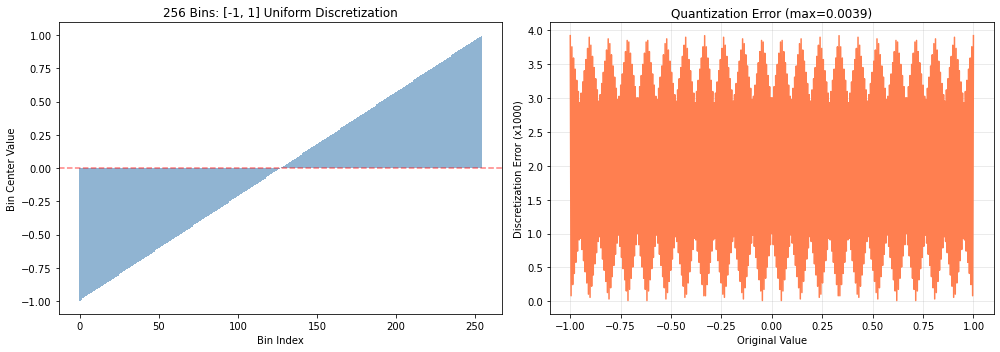


每个 bin 宽度: 0.007812
最大离散化误差: 0.003922
对于 UAV 动作 (量级 ~0.1m)，误差约 0.0020m -> 可忽略


In [11]:
# 可视化离散化过程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: bin 划分
bins = action_tokenizer.bins
centers = action_tokenizer.bin_centers
axes[0].bar(range(len(centers)), centers, width=1.0, color='steelblue', alpha=0.6)
axes[0].set_xlabel('Bin Index')
axes[0].set_ylabel('Bin Center Value')
axes[0].set_title(f'256 Bins: [-1, 1] Uniform Discretization')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# 右图: 离散化精度
test_values = np.linspace(-1, 1, 1000)
bin_indices = np.digitize(test_values, bins)
recovered_values = centers[np.clip(bin_indices - 1, 0, 254)]
errors = np.abs(test_values - recovered_values)

axes[1].plot(test_values, errors * 1000, color='coral')
axes[1].set_xlabel('Original Value')
axes[1].set_ylabel('Discretization Error (x1000)')
axes[1].set_title(f'Quantization Error (max={errors.max():.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n每个 bin 宽度: {2/256:.6f}")
print(f"最大离散化误差: {errors.max():.6f}")
print(f"对于 UAV 动作 (量级 ~0.1m)，误差约 {errors.max() * 0.5:.4f}m -> 可忽略")

## 2.6 Prompt 格式

OpenVLA 使用简洁的 Prompt 格式将任务指令转换为模型输入：

In [12]:
from prismatic.models.backbones.llm.prompting import PurePromptBuilder

# OpenVLA 的 Prompt 格式
prompt_builder = PurePromptBuilder("openvla")

# 模拟一个训练样本的 prompt 构建
proprio = "0.1,0.2,-0.1,15.3"  # 当前状态: x,y,z,yaw
instruction = "fly toward the tree on the left side"
action_tokens = action_tokenizer(np.array([0.1, -0.05, 0.0, 0.2]))  # 模拟动作

prompt_builder.add_turn("human", f"Current State: {proprio}, What action should the uav take to {instruction}?")
prompt_builder.add_turn("gpt", action_tokens)

full_prompt = prompt_builder.get_prompt()
print("完整 Prompt:")
print("=" * 60)
print(full_prompt)
print("=" * 60)

# 推理时的 Prompt (不含 GPT 回复)
print("\n推理时使用的 Prompt:")
inference_prompt = f"In: What action should the robot take to {instruction}?\nOut:"
print(inference_prompt)

完整 Prompt:
In: Current State: 0.1,0.2,-0.1,15.3, What action should the uav take to fly toward the tree on the left side?
Out: 速˚Ÿ麻</s>

推理时使用的 Prompt:
In: What action should the robot take to fly toward the tree on the left side?
Out:


In [13]:
# Token 化过程
tokens = processor.tokenizer(full_prompt, add_special_tokens=True)
input_ids = tokens.input_ids

print(f"Token 总数: {len(input_ids)}")
print(f"\n前 10 个 token ID: {input_ids[:10]}")
print(f"解码: {processor.tokenizer.decode(input_ids[:10])}")
print(f"\n后 10 个 token ID: {input_ids[-10:]}")
print(f"解码: {processor.tokenizer.decode(input_ids[-10:])}")

# 找到动作 token
action_token_start = action_tokenizer.action_token_begin_idx
action_ids = [t for t in input_ids if t >= action_token_start]
print(f"\n动作 token 数量: {len(action_ids)}")
print(f"动作 token IDs: {action_ids}")

Token 总数: 50

前 10 个 token ID: [1, 512, 29901, 9626, 4306, 29901, 29871, 29900, 29889, 29896]
解码: <s> In: Current State: 0.1

后 10 个 token ID: [29973, 13, 3744, 29901, 29871, 31859, 31878, 31872, 31846, 2]
解码: ?
Out: 速˚Ÿ麻</s>

动作 token 数量: 4
动作 token IDs: [31859, 31878, 31872, 31846]


## 2.7 图像处理流程

In [14]:
from PIL import Image

# 加载一张测试图像
DATA_DIR = "/root/autodl-fs/claude/data/uav_flow_subset"
sample_dir = sorted(os.listdir(DATA_DIR))[0]
img_path = os.path.join(DATA_DIR, sample_dir, "000005.jpg")
image = Image.open(img_path).convert("RGB")

print(f"原始图像尺寸: {image.size}")

# 通过 Processor 处理
instruction = "fly toward the tree"
prompt = f"In: What action should the robot take to {instruction}?\nOut:"
inputs = processor(prompt, image)

print(f"\nProcessor 输出:")
for key, val in inputs.items():
    if hasattr(val, 'shape'):
        print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
    else:
        print(f"  {key}: {type(val).__name__}, len={len(val)}")

原始图像尺寸: (256, 256)

Processor 输出:
  input_ids: shape=torch.Size([1, 18]), dtype=torch.int64
  attention_mask: shape=torch.Size([1, 18]), dtype=torch.int64
  pixel_values: shape=torch.Size([1, 6, 224, 224]), dtype=torch.float32


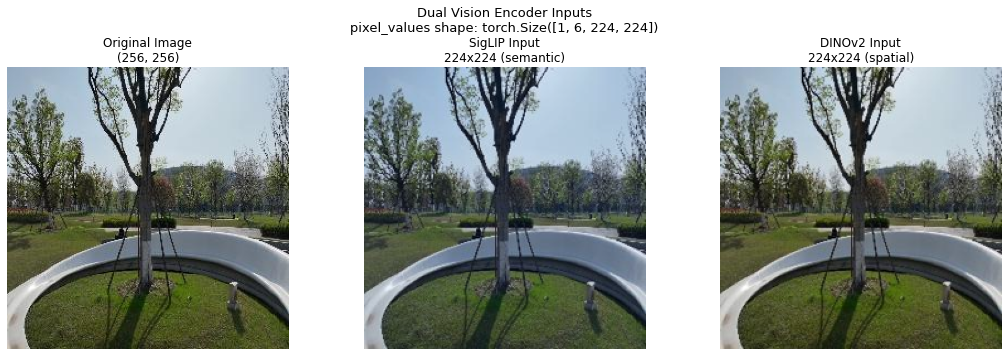

In [15]:
# 可视化: 原始图像 vs 模型输入
pixel_values = inputs['pixel_values']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 原始图像
axes[0].imshow(image)
axes[0].set_title(f'Original Image\n{image.size}')
axes[0].axis('off')

# SigLIP 输入 (前3通道)
siglip_img = pixel_values[0, :3].permute(1, 2, 0).numpy()
siglip_img = (siglip_img - siglip_img.min()) / (siglip_img.max() - siglip_img.min())
axes[1].imshow(siglip_img)
axes[1].set_title(f'SigLIP Input\n224x224 (semantic)')
axes[1].axis('off')

# DINOv2 输入 (后3通道)
dino_img = pixel_values[0, 3:6].permute(1, 2, 0).numpy()
dino_img = (dino_img - dino_img.min()) / (dino_img.max() - dino_img.min())
axes[2].imshow(dino_img)
axes[2].set_title(f'DINOv2 Input\n224x224 (spatial)')
axes[2].axis('off')

plt.suptitle(f'Dual Vision Encoder Inputs\npixel_values shape: {pixel_values.shape}', fontsize=13)
plt.tight_layout()
plt.show()

## 2.8 端到端推理演示

In [16]:
# 用基座模型做一次推理 (未经 UAV 微调, 所以结果不会有意义)
instruction = "fly toward the tree on the left side"
prompt = f"In: What action should the robot take to {instruction}?\nOut:"

inputs = processor(prompt, image).to("cuda:0", dtype=torch.bfloat16)

print(f"指令: {instruction}")
print(f"图像: {img_path}")
print(f"\n生成动作 token...")

with torch.no_grad():
    # 手动生成 token (不用 predict_action, 因为基座模型没有 UAV norm_stats)
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=4,  # 4 维动作
        do_sample=False,
    )

# 提取生成的 token
new_tokens = generated_ids[0, -4:].cpu().numpy()
print(f"生成的 token IDs: {new_tokens}")

# 反离散化
decoded_actions = action_tokenizer.decode_token_ids_to_actions(new_tokens)
print(f"归一化动作 [-1,1]: {decoded_actions}")

dim_names = ['x (前后)', 'y (左右)', 'z (上下)', 'yaw (偏航)']
print(f"\n动作含义:")
for name, val in zip(dim_names, decoded_actions):
    print(f"  {name}: {val:+.4f}")

print("\n[注意] 基座模型未针对 UAV 微调, 预测结果仅供理解流程。")
print("微调后的模型将在 Notebook 03 和 04 中使用。")

指令: fly toward the tree on the left side
图像: /root/autodl-fs/claude/data/uav_flow_subset/2025-04-02_15-25-53/000005.jpg

生成动作 token...
生成的 token IDs: [31795 31811 31872 31952]
归一化动作 [-1,1]: [ 0.60392157  0.47843137  0.         -0.62745098]

动作含义:
  x (前后): +0.6039
  y (左右): +0.4784
  z (上下): +0.0000
  yaw (偏航): -0.6275

[注意] 基座模型未针对 UAV 微调, 预测结果仅供理解流程。
微调后的模型将在 Notebook 03 和 04 中使用。


## 2.9 数据流总结

```
训练时:
  Image ──→ Processor.image_processor ──→ pixel_values [6, 224, 224]
  Text  ──→ Processor.tokenizer       ──→ input_ids [N]
  Action──→ ActionTokenizer            ──→ action tokens (拼接到 labels)
  
  Model forward: pixel_values + input_ids → logits → CrossEntropyLoss

推理时:
  Image + Prompt ──→ Processor ──→ pixel_values + input_ids
  Model.generate ──→ action token IDs
  ActionTokenizer.decode ──→ 归一化动作 [-1, 1]
  De-normalize (使用 q01/q99) ──→ 实际动作值
```

In [17]:
# 清理显存
del model
torch.cuda.empty_cache()
print(f"显存释放完成. 剩余占用: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

显存释放完成. 剩余占用: 15.0 GB


## 小结

- OpenVLA 使用 **双视觉编码器** (SigLIP + DINOv2) 提取互补的图像特征
- 通过 **MLP Projector** 将视觉特征投影到语言空间
- 利用 **Llama 2 7B** 的自回归能力预测动作 token
- **Action Tokenizer** 将连续动作离散化为 256 个 bin，精度足够 (误差 < 0.004)
- Prompt 格式: `In: What action should the robot take to {instruction}?\nOut:`

**下一步:** 在 Notebook 03 中，我们将使用 LoRA 对 OpenVLA 进行无人机动作微调。